In [1]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("="*80)
print("CONFIGURING PROJECT")
print("="*80)

PROJECT_ROOT = r"C:\Users\User\OneDrive\Documents\IoT-Based-Intelligent-Building-DSS"

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "integrated_building_dataset.csv"
)

print("Dataset Exists :", os.path.exists(DATA_PATH))

print("="*80)
print("LOADING DATASET")
print("="*80)

df = pd.read_csv(DATA_PATH)

print(df.shape)

# ----------------------------------------------------------
# Total Energy
# ----------------------------------------------------------

df["Total_Energy"] = (
    df["Academic"] +
    df["Boys_main"] +
    df["Boys_backup"] +
    df["Facilities"] +
    df["Girls_main"] +
    df["Girls_backup"] +
    df["Lecture"] +
    df["Library"] +
    df["Mess"]
)

# ----------------------------------------------------------
# Time Features
# ----------------------------------------------------------

df["datetime"] = pd.to_datetime(df["datetime"])

df["day_of_week"] = df["datetime"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["week_of_year"] = df["datetime"].dt.isocalendar().week.astype(int)
df["quarter"] = df["datetime"].dt.quarter

# ----------------------------------------------------------
# Create Target Classes
# ----------------------------------------------------------

df["Energy_Class"] = pd.qcut(

    df["Total_Energy"],

    q=3,

    labels=[
        "Efficient",
        "Moderate",
        "Critical"
    ]

)

print("="*80)
print("CLASS DISTRIBUTION")
print("="*80)

print(df["Energy_Class"].value_counts())

# ----------------------------------------------------------
# Representative Sample
# ----------------------------------------------------------

df = df.sample(
    n=200000,
    random_state=42
)

print("\nSample Shape :", df.shape)

# ----------------------------------------------------------
# Features
# ----------------------------------------------------------

feature_columns = [

    "year",
    "month",
    "day",
    "hour",

    "day_of_week",
    "is_weekend",
    "week_of_year",
    "quarter",

    "ALLSKY_SFC_SW_DWN",
    "WS2M",
    "PRECTOTCORR"

]

X = df[feature_columns]

y = df["Energy_Class"]

# ----------------------------------------------------------
# Train Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("="*80)
print("TRAIN TEST SPLIT")
print("="*80)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

print("\nNotebook Ready For Model Training")

CONFIGURING PROJECT
Dataset Exists : True
LOADING DATASET
(2310238, 19)
CLASS DISTRIBUTION
Energy_Class
Critical     770080
Efficient    770079
Moderate     770079
Name: count, dtype: int64

Sample Shape : (200000, 25)
TRAIN TEST SPLIT
Training : (160000, 11)
Testing  : (40000, 11)

Notebook Ready For Model Training


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

print("="*80)
print("LABEL ENCODING")
print("="*80)

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

print("="*80)
print("CREATING MODELS")
print("="*80)

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(

        random_state=42,

        objective="multi:softprob",

        num_class=3,

        eval_metric="mlogloss",

        tree_method="hist"

    )

}

results = []

print("="*80)
print("TRAINING MODELS")
print("="*80)

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train_encoded
    )

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_acc = accuracy_score(
        y_train_encoded,
        train_pred
    )

    test_acc = accuracy_score(
        y_test_encoded,
        test_pred
    )

    train_precision = precision_score(
        y_train_encoded,
        train_pred,
        average="weighted"
    )

    test_precision = precision_score(
        y_test_encoded,
        test_pred,
        average="weighted"
    )

    train_recall = recall_score(
        y_train_encoded,
        train_pred,
        average="weighted"
    )

    test_recall = recall_score(
        y_test_encoded,
        test_pred,
        average="weighted"
    )

    train_f1 = f1_score(
        y_train_encoded,
        train_pred,
        average="weighted"
    )

    test_f1 = f1_score(
        y_test_encoded,
        test_pred,
        average="weighted"
    )

    train_auc = roc_auc_score(
        y_train_encoded,
        model.predict_proba(X_train),
        multi_class="ovr"
    )

    test_auc = roc_auc_score(
        y_test_encoded,
        model.predict_proba(X_test),
        multi_class="ovr"
    )

    results.append([

        name,

        train_acc,
        test_acc,

        train_precision,
        test_precision,

        train_recall,
        test_recall,

        train_f1,
        test_f1,

        train_auc,
        test_auc

    ])

print("\nAll Models Trained Successfully")

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Train Accuracy",
        "Test Accuracy",

        "Train Precision",
        "Test Precision",

        "Train Recall",
        "Test Recall",

        "Train F1",
        "Test F1",

        "Train ROC-AUC",
        "Test ROC-AUC"

    ]

)

results_df = results_df.sort_values(

    by="Test Accuracy",

    ascending=False

).reset_index(drop=True)

print("="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)

display(results_df)

LABEL ENCODING
['Critical' 'Efficient' 'Moderate']
CREATING MODELS
TRAINING MODELS

Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Training XGBoost...

All Models Trained Successfully
MODEL PERFORMANCE COMPARISON


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Random Forest,0.938531,0.907400,0.938565,0.907542,0.938531,0.907400,0.938547,0.907467,0.994430,0.978678
1,Decision Tree,0.938531,0.905550,0.938288,0.904925,0.938531,0.905550,0.938226,0.905027,0.994502,0.967318
2,XGBoost,0.891513,0.881100,0.891898,0.881570,0.891513,0.881100,0.891677,0.881298,0.977842,0.972302
3,Gradient Boosting,0.751644,0.750725,0.750566,0.749141,0.751644,0.750725,0.751042,0.749815,0.906578,0.905441
4,Logistic Regression,0.520644,0.518200,0.516347,0.514043,0.520644,0.518200,0.516737,0.514189,0.691894,0.689754


In [3]:
# ==========================================================
# Steps 11-15
# 11. Hyperparameter Tuning
# 12. Select Best Models
# 13. Evaluate Tuned Models
# 14. Compare Performance
# 15. Save Final Model
# ==========================================================

from sklearn.model_selection import GridSearchCV
import joblib

print("="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

# ----------------------------------------------------------
# Top 3 Models
# ----------------------------------------------------------

tuning_models = {

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(

        random_state=42,

        objective="multi:softprob",

        num_class=3,

        eval_metric="mlogloss",

        tree_method="hist"

    )

}

# ----------------------------------------------------------
# Common Parameter Grid
# ----------------------------------------------------------

param_grid = {

    "n_estimators":[50,100],

    "max_depth":[5,10],

    "learning_rate":[0.05,0.1]

}

best_models = {}

tuned_results = []

# ----------------------------------------------------------
# Grid Search
# ----------------------------------------------------------

for name, model in tuning_models.items():

    print(f"\nTuning {name}...")

    valid_params = {

        k:v

        for k,v in param_grid.items()

        if k in model.get_params()

    }

    grid = GridSearchCV(

        estimator=model,

        param_grid=valid_params,

        cv=3,

        scoring="accuracy",

        n_jobs=-1,

        verbose=2

    )

    grid.fit(

        X_train,

        y_train_encoded

    )

    best_models[name] = grid.best_estimator_

    test_pred = grid.best_estimator_.predict(X_test)

    tuned_results.append([

        name,

        grid.best_score_,

        accuracy_score(

            y_test_encoded,

            test_pred

        ),

        precision_score(

            y_test_encoded,

            test_pred,

            average="weighted"

        ),

        recall_score(

            y_test_encoded,

            test_pred,

            average="weighted"

        ),

        f1_score(

            y_test_encoded,

            test_pred,

            average="weighted"

        ),

        roc_auc_score(

            y_test_encoded,

            grid.best_estimator_.predict_proba(X_test),

            multi_class="ovr"

        ),

        grid.best_params_

    ])

# ----------------------------------------------------------
# Results
# ----------------------------------------------------------

tuned_df = pd.DataFrame(

    tuned_results,

    columns=[

        "Model",

        "CV Accuracy",

        "Test Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC",

        "Best Parameters"

    ]

)

tuned_df = tuned_df.sort_values(

    by="Test Accuracy",

    ascending=False

).reset_index(drop=True)

print("="*100)
print("TUNED MODEL COMPARISON")
print("="*100)

display(tuned_df)

# ----------------------------------------------------------
# Final Model
# ----------------------------------------------------------

final_classifier = best_models[

    tuned_df.iloc[0]["Model"]

]

print("="*80)
print("FINAL CLASSIFICATION MODEL")
print("="*80)

print(tuned_df.iloc[0]["Model"])

# ----------------------------------------------------------
# Save Model
# ----------------------------------------------------------

CLASSIFIER_DIR = os.path.join(

    PROJECT_ROOT,

    "models"

)

os.makedirs(

    CLASSIFIER_DIR,

    exist_ok=True

)

joblib.dump(

    final_classifier,

    os.path.join(

        CLASSIFIER_DIR,

        "final_classifier.pkl"

    )

)

joblib.dump(

    label_encoder,

    os.path.join(

        CLASSIFIER_DIR,

        "label_encoder.pkl"

    )

)

tuned_df.to_csv(

    os.path.join(

        CLASSIFIER_DIR,

        "classification_results.csv"

    ),

    index=False

)

print("\nClassification Model Saved Successfully")

HYPERPARAMETER TUNING

Tuning Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Tuning Gradient Boosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Tuning XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
TUNED MODEL COMPARISON


,Model,CV Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Best Parameters
0,Gradient Boosting,0.906575,0.910525,0.910855,0.910525,0.910670,0.983224,"{'learning_rate': 0.1, 'max_depth': 10, 'n_est..."
1,XGBoost,0.899650,0.901825,0.902190,0.901825,0.901987,0.980660,"{'learning_rate': 0.1, 'max_depth': 10, 'n_est..."
2,Random Forest,0.807656,0.805125,0.807027,0.805125,0.805702,0.937239,"{'max_depth': 10, 'n_estimators': 100}"


FINAL CLASSIFICATION MODEL
Gradient Boosting

Classification Model Saved Successfully


FINAL MODEL EVALUATION


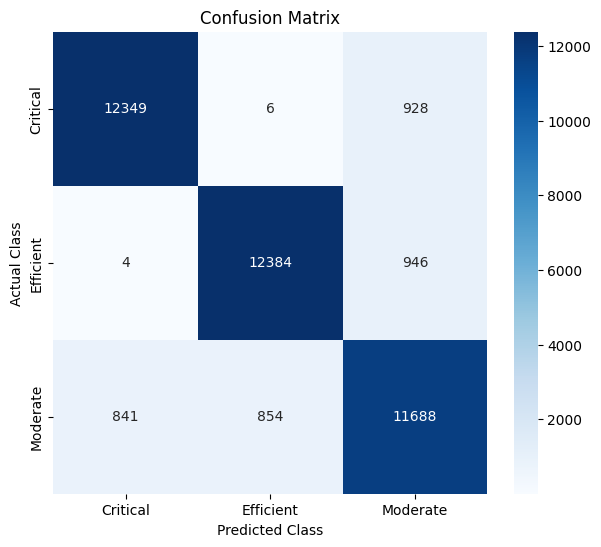

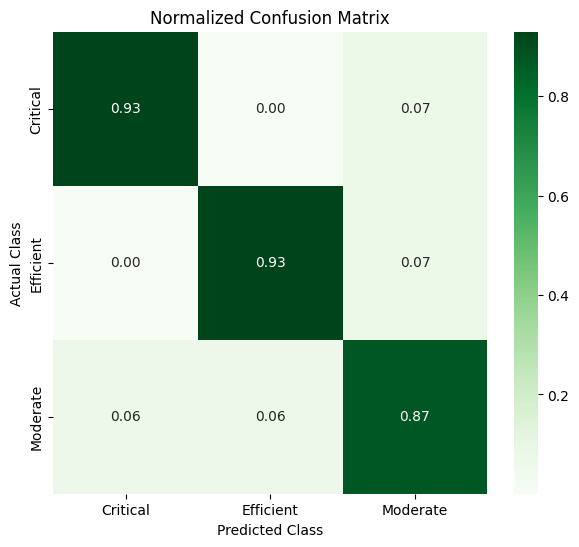

CLASSIFICATION REPORT


,precision,recall,f1-score,support
Critical,0.935956,0.929685,0.932810,13283.000000
Efficient,0.935065,0.928754,0.931899,13334.000000
Moderate,0.861820,0.873347,0.867545,13383.000000
accuracy,0.910525,0.910525,0.910525,0.910525
macro avg,0.910947,0.910595,0.910751,40000.000000
weighted avg,0.910855,0.910525,0.910670,40000.000000


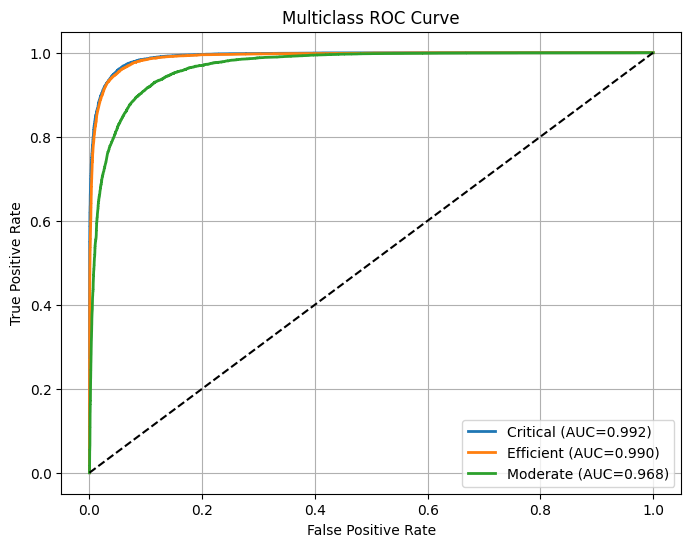

FEATURE IMPORTANCE


,Feature,Importance
3,hour,0.254211
6,week_of_year,0.221670
0,year,0.160371
1,month,0.094973
8,ALLSKY_SFC_SW_DWN,0.061698
2,day,0.049870
4,day_of_week,0.049312
9,WS2M,0.042489
5,is_weekend,0.029680
10,PRECTOTCORR,0.020387


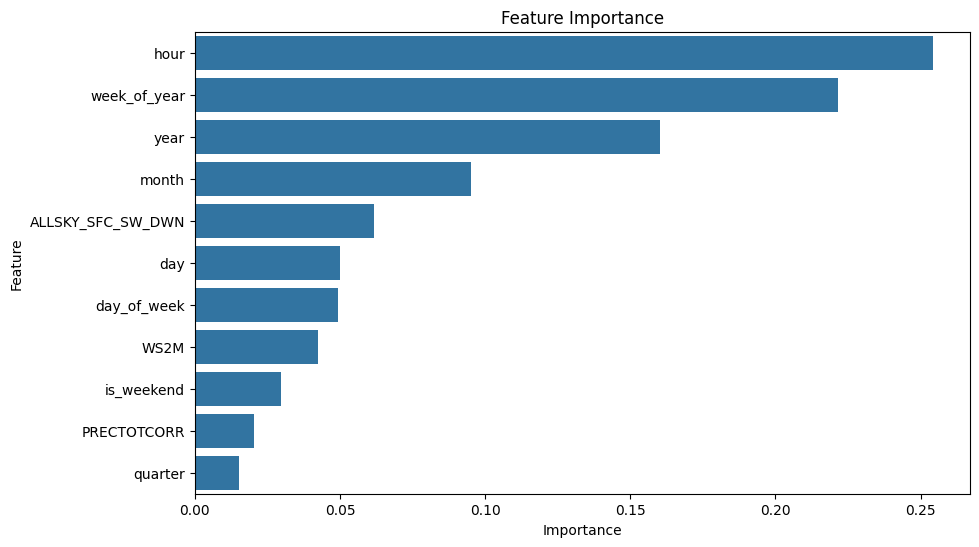

CLASSIFICATION COMPLETED SUCCESSFULLY

Saved Files
----------------------------------------
best_xgboost_parameters.csv
classification_feature_importance.csv
classification_report.csv
classification_results.csv
evaluation_metrics.csv
feature_importance.csv
feature_names.pkl
final_classifier.pkl
final_model_performance.csv
final_xgboost_model.pkl
hyperparameter_results.csv
label_encoder.pkl
prediction_results.csv
shap_feature_importance.csv
shap_values.csv
test_dataset.csv
train_dataset.csv


In [5]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("="*80)
print("FINAL MODEL EVALUATION")
print("="*80)

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

y_pred = final_classifier.predict(X_test)

y_prob = final_classifier.predict_proba(X_test)

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

# ----------------------------------------------------------
# Normalized Confusion Matrix
# ----------------------------------------------------------

cm_normalized = confusion_matrix(
    y_test_encoded,
    y_pred,
    normalize="true"
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Normalized Confusion Matrix")

plt.show()

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("="*80)
print("CLASSIFICATION REPORT")
print("="*80)

report = classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

# ----------------------------------------------------------
# Multiclass ROC Curve (One-vs-Rest)
# ----------------------------------------------------------

y_test_bin = label_binarize(
    y_test_encoded,
    classes=[0,1,2]
)

plt.figure(figsize=(8,6))

for i, class_name in enumerate(label_encoder.classes_):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        y_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------

if hasattr(final_classifier,"feature_importances_"):

    importance = pd.DataFrame({

        "Feature":X_train.columns,

        "Importance":final_classifier.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    display(importance)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Feature Importance")

    plt.show()

# ----------------------------------------------------------
# Save Results
# ----------------------------------------------------------

report_df.to_csv(
    os.path.join(
        CLASSIFIER_DIR,
        "classification_report.csv"
    ),
    index=True
)

if hasattr(final_classifier,"feature_importances_"):

    importance.to_csv(
        os.path.join(
            CLASSIFIER_DIR,
            "classification_feature_importance.csv"
        ),
        index=False
    )

print("="*80)
print("CLASSIFICATION COMPLETED SUCCESSFULLY")
print("="*80)

print("\nSaved Files")
print("-"*40)

for file in os.listdir(CLASSIFIER_DIR):
    print(file)